# 1. Project Overview

**Project:** Vehicle Insurance Claim Validator — Master's Project

This notebook implements the **Image Input Validation** phase, including the new **runtime human-review fallback** logic. It ends with a validated image dataset ready for the next phase: **Vehicle Damage Detection** (not implemented here).

## Final runtime pipeline

```
                    CUSTOMER IMAGE
                          |
                AUTOMATED QUALITY CHECK
                  Technical + MANIQA
                          |
                  +-------+-------+
                  |               |
                PASS             FAIL
                  |               |
                  |         HUMAN QUALITY REVIEW
                  |               |
                  |          +----+----+
                  |         YES       NO
                  |          |         |
                  +----------+       REJECT
                         |
                VEHICLE DETECTION (YOLO)
                         |
                  +------+------+
                  |             |
               DETECTED     NOT DETECTED
                  |             |
                  |       HUMAN VEHICLE REVIEW
                  |             |
                  |        +----+----+
                  |       YES       NO
                  |        |         |
                  +--------+       REJECT
                         |
                 DAMAGE DETECTION
                  (next phase — not in this notebook)
```

## Two kinds of human review — not the same thing

- **A) Validation / development human review** — the existing 100-image labeled set
  (`manual_labels_100.csv`) used to *calibrate and evaluate* the automated quality thresholds
  and the YOLO experiment. This is historical, fixed, and never treated as runtime input.
- **B) Runtime fallback human review** — new in this notebook. Triggered only for images the
  automated system rejects or is uncertain about, at the time the image arrives. Produces two
  resumable review queues: `quality_human_review_queue.csv` and `yolo_human_review_queue.csv`.

These two datasets are kept completely separate throughout.

# 2. Environment and GPU Setup

Installs and GPU checks for both MANIQA (image quality) and YOLO (vehicle detection), used later in the notebook. Skip the install cell if packages are already present.

In [5]:
# Install required packages (skip if already installed in this environment)
!pip install -q pyiqa opencv-python-headless ultralytics easyocr


[notice] A new release of pip is available: 25.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import os
import torch
import pyiqa
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, clear_output
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


def get_device():
    """Use GPU when available, fall back to CPU otherwise."""
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        return torch.device("cuda:0")
    print("WARNING: CUDA not available — using CPU (slower).")
    return torch.device("cpu")


device = get_device()
print("Using device:", device)

# MANIQA — loaded once, reused everywhere in this notebook
metric = pyiqa.create_metric("maniqa", device=device)
print("MANIQA device:", next(metric.parameters()).device)

GPU: NVIDIA A16
Using device: cuda:0


Loading pretrained model MANIQA from /home/jovyan/.cache/torch/hub/pyiqa/ckpt_koniq10k.pt
MANIQA device: cuda:0


# 3. Dataset Loading

In [7]:
data_path = "/home/jovyan/car_damage/images"

image_files = []
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Dataset path:", data_path)
print("Total images found:", len(image_files))

Dataset path: /home/jovyan/car_damage/images
Total images found: 8079


# 4. Initial Exploratory Analysis (500-Image Sample)

A 500-image sample is scored on both technical checks and MANIQA to understand the shape of each metric before calibration. If a saved result file exists it is loaded instead of recomputing.

In [8]:
def score_image(image_path, metric):
    """Compute technical + MANIQA scores for a single image. Returns None if unreadable."""
    image = cv2.imread(image_path)
    if image is None:
        return None

    height, width = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = np.mean(gray)
    contrast = gray.std()

    resolution_ok = width >= 640 and height >= 480
    blur_ok = blur_score >= 100
    brightness_ok = 40 <= brightness <= 220
    contrast_ok = contrast >= 30
    technical_pass = all([resolution_ok, blur_ok, brightness_ok, contrast_ok])

    maniqa_score = metric(image_path).item() * 100

    return {
        "image": os.path.basename(image_path),
        "image_path": image_path,
        "maniqa_score": maniqa_score,
        "width": width,
        "height": height,
        "resolution_ok": resolution_ok,
        "blur_score": blur_score,
        "blur_ok": blur_ok,
        "brightness": brightness,
        "brightness_ok": brightness_ok,
        "contrast": contrast,
        "contrast_ok": contrast_ok,
        "technical_pass": technical_pass,
    }

In [9]:
exploratory_file = "/home/jovyan/car_damage/quality_results/quality_results_500.csv"

if os.path.exists(exploratory_file):
    df = pd.read_csv(exploratory_file)
    print("Loaded saved exploratory results:", exploratory_file)
else:
    results = [score_image(p, metric) for p in tqdm(image_files[:500], desc="Scoring 500-image sample")]
    df = pd.DataFrame([r for r in results if r is not None])
    os.makedirs(os.path.dirname(exploratory_file), exist_ok=True)
    df.to_csv(exploratory_file, index=False)
    print("Computed and saved exploratory results:", exploratory_file)

print("Images in exploratory sample:", len(df))
df.head()

Loaded saved exploratory results: /home/jovyan/car_damage/quality_results/quality_results_500.csv
Images in exploratory sample: 500


,image,image_path,maniqa_score,width,height,resolution_ok,blur_score,blur_ok,brightness,brightness_ok,contrast,contrast_ok,technical_pass
0,4187.jpg,/home/jovyan/car_damage/images/4187.jpg,19.842455,1305,978,True,76.991008,False,129.760910,True,67.993394,True,False
1,7447.jpg,/home/jovyan/car_damage/images/7447.jpg,20.007588,874,655,True,27.543362,False,105.005798,True,62.063880,True,False
2,2713.jpg,/home/jovyan/car_damage/images/2713.jpg,28.176823,1147,860,True,22.067243,False,113.081336,True,45.884044,True,False
3,3649.jpg,/home/jovyan/car_damage/images/3649.jpg,32.767910,838,628,True,394.606560,True,97.461445,True,39.926535,True,True
4,4025.jpg,/home/jovyan/car_damage/images/4025.jpg,36.128667,878,658,True,133.070428,True,134.648869,True,29.926585,False,False


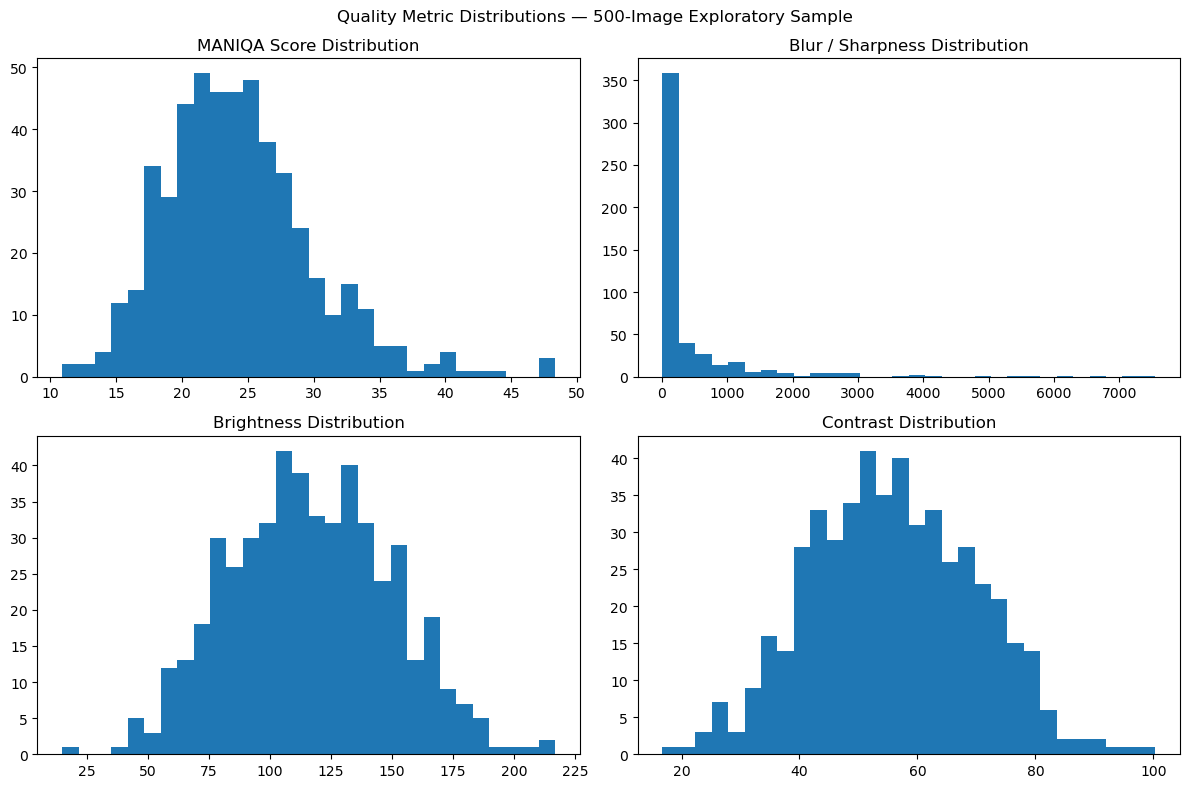

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["maniqa_score"], bins=30)
axes[0, 0].set_title("MANIQA Score Distribution")

axes[0, 1].hist(df["blur_score"], bins=30)
axes[0, 1].set_title("Blur / Sharpness Distribution")

axes[1, 0].hist(df["brightness"], bins=30)
axes[1, 0].set_title("Brightness Distribution")

axes[1, 1].hist(df["contrast"], bins=30)
axes[1, 1].set_title("Contrast Distribution")

fig.suptitle("Quality Metric Distributions — 500-Image Exploratory Sample")
plt.tight_layout()
plt.show()

# 5. Technical Image Quality Metrics

Four technical signals are computed per image: **resolution**, **blur/sharpness** (Laplacian variance), **brightness** (mean gray-level), and **contrast** (gray-level std. dev.). These are cheap to compute and run before MANIQA.

In [11]:
print("Technical PASS / FAIL — 500-image sample")
print(df["technical_pass"].value_counts())
print(df["technical_pass"].value_counts(normalize=True).mul(100).round(2))

print("\nPercentiles (500-image sample):")
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
display(df[["blur_score", "brightness", "contrast"]].quantile(percentiles))

Technical PASS / FAIL — 500-image sample
technical_pass
False    264
True     236
Name: count, dtype: int64
technical_pass
False    52.8
True     47.2
Name: proportion, dtype: float64

Percentiles (500-image sample):


,blur_score,brightness,contrast
0.01,11.010552,45.779843,25.600922
0.05,14.523477,63.426111,34.144324
0.10,20.617162,75.028539,38.650826
0.25,40.082125,93.408762,45.674957
0.50,92.966366,115.796419,55.170478
0.75,333.278644,139.991205,66.016394
0.90,1132.021598,158.865899,74.076608
0.95,2198.448355,170.762434,79.263776
0.99,5370.921786,188.662914,88.445923


# 6. MANIQA Image Quality Assessment

MANIQA is a no-reference perceptual image-quality model — it scores an image's *perceived* quality without needing a clean reference image, complementing the technical checks above.

In [12]:
print("MANIQA Percentiles (500-image sample):")
display(df["maniqa_score"].quantile(percentiles))

MANIQA Percentiles (500-image sample):


0.01    14.140615
0.05    16.497929
0.10    17.895746
0.25    20.464166
0.50    23.772465
0.75    27.331384
0.90    31.621019
0.95    34.291493
0.99    41.193723
Name: maniqa_score, dtype: float64

# 7. Human Validation and Threshold Calibration

**A) Validation / development human review.** A 100-image sample was manually labeled GOOD/BAD and used as ground truth to calibrate the technical + MANIQA thresholds. This dataset (`manual_df`) is historical and is never used as runtime review input (see Section 10 for that).

In [13]:
manual_labels_file = "/home/jovyan/car_damage/manual_labels_100.csv"

manual_df = pd.read_csv(manual_labels_file)
manual_df["human_label"] = manual_df["human_label"].astype(str).str.strip().str.upper()
manual_df["human_binary"] = (manual_df["human_label"] == "GOOD").astype(int)  # GOOD = 1, BAD = 0

print("Images reviewed:", len(manual_df))
print(manual_df["human_label"].value_counts())
manual_df.head()

Images reviewed: 100
human_label
BAD     66
GOOD    34
Name: count, dtype: int64


,image,image_path,maniqa_score,width,height,resolution_ok,blur_score,blur_ok,brightness,brightness_ok,contrast,contrast_ok,technical_pass,human_label,human_binary
0,1437.jpg,/home/jovyan/car_damage/images/1437.jpg,24.085917,830,622,True,236.164874,True,165.832069,True,74.482521,True,True,GOOD,1
1,4609.jpg,/home/jovyan/car_damage/images/4609.jpg,32.992083,1336,1002,True,15.862947,False,119.748823,True,43.746787,True,False,BAD,0
2,4226.jpg,/home/jovyan/car_damage/images/4226.jpg,21.616083,1124,843,True,44.103098,False,178.290805,True,83.083486,True,False,BAD,0
3,4675.jpg,/home/jovyan/car_damage/images/4675.jpg,25.756788,1383,1037,True,72.788142,False,61.129793,True,39.169311,True,False,BAD,0
4,7414.jpg,/home/jovyan/car_damage/images/7414.jpg,20.754808,860,645,True,1880.053588,True,98.663703,True,47.129298,True,True,GOOD,1


### 7.1 Baseline: Technical Checks vs. Human Review

In [14]:
def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


technical_pred = manual_df["technical_pass"].astype(int)
technical_metrics = evaluate_predictions(manual_df["human_binary"], technical_pred)

print("Technical Check vs. Human Review")
for k, v in technical_metrics.items():
    print(f"{k.capitalize():10s}: {v*100:.1f}%")

tn, fp, fn, tp = confusion_matrix(manual_df["human_binary"], technical_pred, labels=[0, 1]).ravel()
print(f"\nConfusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}")

Technical Check vs. Human Review
Accuracy  : 64.0%
Precision : 47.9%
Recall    : 67.6%
F1        : 56.1%

Confusion Matrix: TN=41  FP=25  FN=11  TP=23


### 7.2 Individual Threshold Sweeps

In [15]:
# MANIQA
maniqa_results = []
for t in range(10, 41):
    pred = (manual_df["maniqa_score"] >= t).astype(int)
    maniqa_results.append({"threshold": t, **evaluate_predictions(manual_df["human_binary"], pred)})
maniqa_results_df = pd.DataFrame(maniqa_results)
best_maniqa = maniqa_results_df.loc[maniqa_results_df["f1"].idxmax()]
print("Best MANIQA threshold (single-metric):", best_maniqa["threshold"])

Best MANIQA threshold (single-metric): 19.0


In [16]:
# Blur
blur_results = []
for t in np.arange(0, int(manual_df["blur_score"].max()) + 1, 10):
    pred = (manual_df["blur_score"] >= t).astype(int)
    blur_results.append({"blur_threshold": t, **evaluate_predictions(manual_df["human_binary"], pred)})
blur_results_df = pd.DataFrame(blur_results)
display(blur_results_df.sort_values("f1", ascending=False).head(5))

,blur_threshold,accuracy,precision,recall,f1
7,70,0.62,0.465517,0.794118,0.586957
9,90,0.64,0.480000,0.705882,0.571429
6,60,0.57,0.428571,0.794118,0.556701
10,100,0.63,0.469388,0.676471,0.554217
8,80,0.61,0.452830,0.705882,0.551724


In [17]:
# Contrast
contrast_results = []
for t in np.arange(10, 81, 5):
    pred = (manual_df["contrast"] >= t).astype(int)
    contrast_results.append({"contrast_threshold": t, **evaluate_predictions(manual_df["human_binary"], pred)})
contrast_results_df = pd.DataFrame(contrast_results)
display(contrast_results_df.sort_values("f1", ascending=False).head(5))

,contrast_threshold,accuracy,precision,recall,f1
6,40,0.44,0.369048,0.911765,0.525424
5,35,0.37,0.350515,1.000000,0.519084
4,30,0.35,0.343434,1.000000,0.511278
7,45,0.46,0.368421,0.823529,0.509091
2,20,0.34,0.340000,1.000000,0.507463


In [18]:
# Brightness range
brightness_results = []
for low, high in [(20, 200), (30, 210), (40, 220), (50, 210), (50, 220), (60, 200), (60, 220), (70, 210), (70, 220)]:
    pred = manual_df["brightness"].between(low, high).astype(int)
    brightness_results.append({"min_brightness": low, "max_brightness": high, **evaluate_predictions(manual_df["human_binary"], pred)})
brightness_results_df = pd.DataFrame(brightness_results)
display(brightness_results_df.sort_values("f1", ascending=False))

,min_brightness,max_brightness,accuracy,precision,recall,f1
7,70,210,0.40,0.355556,0.941176,0.516129
8,70,220,0.40,0.355556,0.941176,0.516129
5,60,200,0.37,0.347368,0.970588,0.511628
0,20,200,0.35,0.343434,1.000000,0.511278
2,40,220,0.35,0.343434,1.000000,0.511278
3,50,210,0.35,0.343434,1.000000,0.511278
4,50,220,0.35,0.343434,1.000000,0.511278
6,60,220,0.36,0.343750,0.970588,0.507692
1,30,210,0.34,0.340000,1.000000,0.507463


### 7.3 Joint Threshold Optimization

In [19]:
maniqa_grid = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30]
blur_grid = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
contrast_grid = [25, 30, 35, 40, 45, 50, 55, 60]
brightness_grid = [(40, 200), (40, 210), (40, 220), (50, 200), (50, 210), (50, 220), (60, 200), (60, 210), (60, 220)]

y_true = manual_df["human_binary"]
joint_search_results = []

for maniqa_th in maniqa_grid:
    for blur_th in blur_grid:
        for contrast_th in contrast_grid:
            for b_min, b_max in brightness_grid:
                prediction = (
                    (manual_df["maniqa_score"] >= maniqa_th)
                    & (manual_df["blur_score"] >= blur_th)
                    & (manual_df["contrast"] >= contrast_th)
                    & (manual_df["brightness"].between(b_min, b_max))
                ).astype(int)

                metrics = evaluate_predictions(y_true, prediction)
                tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()

                joint_search_results.append({
                    "maniqa_threshold": maniqa_th, "blur_threshold": blur_th,
                    "contrast_threshold": contrast_th,
                    "brightness_min": b_min, "brightness_max": b_max,
                    **metrics, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                })

joint_results = pd.DataFrame(joint_search_results).sort_values("f1", ascending=False).reset_index(drop=True)
display(joint_results.head(10))

,maniqa_threshold,blur_threshold,contrast_threshold,brightness_min,brightness_max,accuracy,precision,recall,f1,TN,FP,FN,TP
0,20,70,40,50,200,0.78,0.666667,0.705882,0.685714,54,12,10,24
1,20,70,40,40,200,0.78,0.666667,0.705882,0.685714,54,12,10,24
2,20,70,40,60,200,0.78,0.666667,0.705882,0.685714,54,12,10,24
3,19,70,40,60,200,0.77,0.641026,0.735294,0.684932,52,14,9,25
4,20,70,40,40,210,0.77,0.648649,0.705882,0.676056,53,13,10,24
5,20,70,40,50,210,0.77,0.648649,0.705882,0.676056,53,13,10,24
6,20,70,40,40,220,0.77,0.648649,0.705882,0.676056,53,13,10,24
7,20,70,40,60,210,0.77,0.648649,0.705882,0.676056,53,13,10,24
8,20,70,40,50,220,0.77,0.648649,0.705882,0.676056,53,13,10,24
9,20,70,40,60,220,0.77,0.648649,0.705882,0.676056,53,13,10,24


### 7.4 Final Calibrated Thresholds

These are the final, locked thresholds used everywhere downstream in this notebook — they are **not** re-derived or changed after this point.

In [ ]:
# FINAL CALIBRATED THRESHOLDS — locked, reused in every later section
FINAL_THRESHOLDS = {
    "MANIQA": 15,
    "BLUR": 40,
    "CONTRAST": 30,
    "BRIGHTNESS_MIN": 35,
    "BRIGHTNESS_MAX": 220,
}

final_pred = (
    (manual_df["maniqa_score"] >= FINAL_THRESHOLDS["MANIQA"])
    & (manual_df["blur_score"] >= FINAL_THRESHOLDS["BLUR"])
    & (manual_df["contrast"] >= FINAL_THRESHOLDS["CONTRAST"])
    & (manual_df["brightness"].between(FINAL_THRESHOLDS["BRIGHTNESS_MIN"], FINAL_THRESHOLDS["BRIGHTNESS_MAX"]))
).astype(int)

final_metrics = evaluate_predictions(manual_df["human_binary"], final_pred)
tn, fp, fn, tp = confusion_matrix(manual_df["human_binary"], final_pred, labels=[0, 1]).ravel()

print("FINAL CALIBRATED QUALITY PIPELINE — vs. Human Review (100 images)")
print("=" * 60)
maniqa_t = FINAL_THRESHOLDS["MANIQA"]
blur_t = FINAL_THRESHOLDS["BLUR"]
contrast_t = FINAL_THRESHOLDS["CONTRAST"]
bright_min = FINAL_THRESHOLDS["BRIGHTNESS_MIN"]
bright_max = FINAL_THRESHOLDS["BRIGHTNESS_MAX"]
print(f"MANIQA >= {maniqa_t}, Blur >= {blur_t}, Contrast >= {contrast_t}, "
      f"Brightness in [{bright_min}, {bright_max}]")
for k, v in final_metrics.items():
    print(f"{k.capitalize():10s}: {v*100:.1f}%")
print(f"\nConfusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}")

FINAL CALIBRATED QUALITY PIPELINE — vs. Human Review (100 images)
MANIQA >= 20, Blur >= 70, Contrast >= 40, Brightness in [50, 200]
Accuracy  : 78.0%
Precision : 66.7%
Recall    : 70.6%
F1        : 68.6%

Confusion Matrix: TN=54  FP=12  FN=10  TP=24


# 8. Final Quality Gate on 8,079 Images

MANIQA is **not** recomputed if a saved raw-score file already exists. The calibrated thresholds from Section 7.4 are then applied to produce the automated quality decision for every image.

In [21]:
raw_scores_file = "/home/jovyan/car_damage/quality_results_8000.csv"

if os.path.exists(raw_scores_file):
    df_8000 = pd.read_csv(raw_scores_file)
    print("Loaded saved raw scores:", raw_scores_file)
else:
    print("No saved raw scores found — scoring all images (this is expensive).")
    results = [score_image(p, metric) for p in tqdm(image_files, desc="Scoring full dataset")]
    df_8000 = pd.DataFrame([r for r in results if r is not None])
    df_8000.to_csv(raw_scores_file, index=False)
    print("Saved raw scores:", raw_scores_file)

print("Total images:", len(df_8000))

Loaded saved raw scores: /home/jovyan/car_damage/quality_results_8000.csv
Total images: 8079


In [22]:
# Apply the final calibrated thresholds (Section 7.4) — automated decision only, no human input yet
df_8000["technical_pass"] = (
    (df_8000["width"] >= 640) & (df_8000["height"] >= 480)
    & (df_8000["blur_score"] >= FINAL_THRESHOLDS["BLUR"])
    & (df_8000["brightness"].between(FINAL_THRESHOLDS["BRIGHTNESS_MIN"], FINAL_THRESHOLDS["BRIGHTNESS_MAX"]))
    & (df_8000["contrast"] >= FINAL_THRESHOLDS["CONTRAST"])
)

df_8000["maniqa_pass"] = df_8000["maniqa_score"] >= FINAL_THRESHOLDS["MANIQA"]

df_8000["automated_quality_pass"] = df_8000["technical_pass"] & df_8000["maniqa_pass"]

# Per-check breakdown (for failure-reason analysis in Section 9)
df_8000["resolution_pass"] = (df_8000["width"] >= 640) & (df_8000["height"] >= 480)
df_8000["blur_pass"] = df_8000["blur_score"] >= FINAL_THRESHOLDS["BLUR"]
df_8000["brightness_pass"] = df_8000["brightness"].between(FINAL_THRESHOLDS["BRIGHTNESS_MIN"], FINAL_THRESHOLDS["BRIGHTNESS_MAX"])
df_8000["contrast_pass"] = df_8000["contrast"] >= FINAL_THRESHOLDS["CONTRAST"]

total = len(df_8000)
technical_pass_n = int(df_8000["technical_pass"].sum())
maniqa_pass_n = int(df_8000["maniqa_pass"].sum())
automated_pass_n = int(df_8000["automated_quality_pass"].sum())

print("AUTOMATED QUALITY GATE — 8,079 IMAGES")
print("=" * 60)
print(f"Total images        : {total}")
print(f"Technical PASS       : {technical_pass_n} ({technical_pass_n/total*100:.2f}%)")
print(f"Technical FAIL       : {total-technical_pass_n} ({(total-technical_pass_n)/total*100:.2f}%)")
print(f"MANIQA PASS          : {maniqa_pass_n} ({maniqa_pass_n/total*100:.2f}%)")
print(f"MANIQA FAIL          : {total-maniqa_pass_n} ({(total-maniqa_pass_n)/total*100:.2f}%)")
print(f"Automated Quality PASS : {automated_pass_n} ({automated_pass_n/total*100:.2f}%)")
print(f"Automated Quality FAIL : {total-automated_pass_n} ({(total-automated_pass_n)/total*100:.2f}%)")

final_quality_file = "/home/jovyan/car_damage/final_quality_results_8079.csv"
df_8000.to_csv(final_quality_file, index=False)
print("\nSaved:", final_quality_file)

AUTOMATED QUALITY GATE — 8,079 IMAGES
Total images        : 8079
Technical PASS       : 4061 (50.27%)
Technical FAIL       : 4018 (49.73%)
MANIQA PASS          : 6061 (75.02%)
MANIQA FAIL          : 2018 (24.98%)
Automated Quality PASS : 3258 (40.33%)
Automated Quality FAIL : 4821 (59.67%)

Saved: /home/jovyan/car_damage/final_quality_results_8079.csv


# 9. Failure Reason Analysis

Breaks down *why* automatically-rejected images failed (an image can fail more than one check).

In [23]:
def get_failure_reason(row):
    reasons = []
    if not row["resolution_pass"]:
        reasons.append("Resolution")
    if not row["blur_pass"]:
        reasons.append("Blur")
    if not row["brightness_pass"]:
        reasons.append("Brightness")
    if not row["contrast_pass"]:
        reasons.append("Contrast")
    if not row["maniqa_pass"]:
        reasons.append("MANIQA")
    return "PASS" if not reasons else " + ".join(reasons)


df_8000["failure_reason"] = df_8000.apply(get_failure_reason, axis=1)
failure_counts = df_8000["failure_reason"].value_counts()
display(failure_counts.to_frame("count"))

,count
failure_reason,
PASS,3258
Blur,1926
Blur + MANIQA,1041
MANIQA,803
Blur + Contrast,394
Contrast,355
Blur + Contrast + MANIQA,85
Brightness,44
Contrast + MANIQA,41


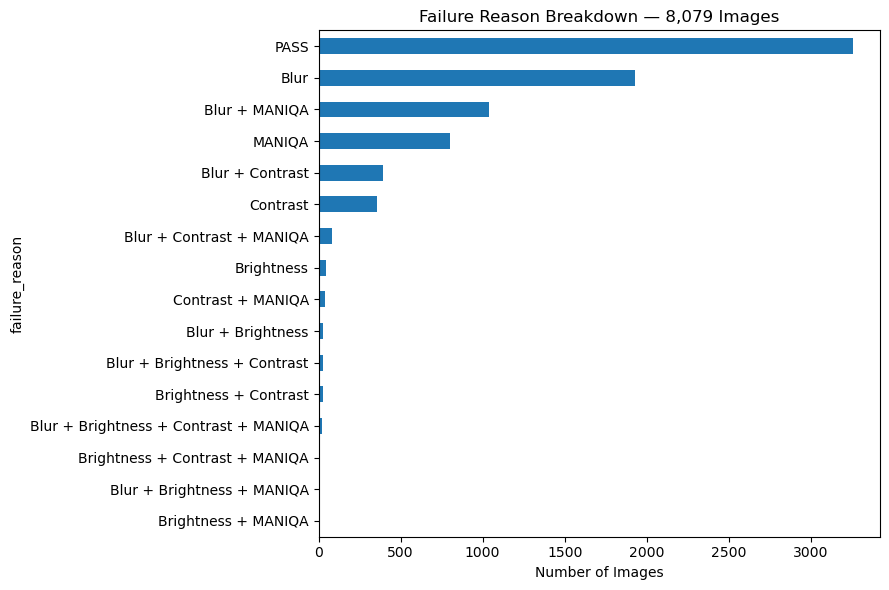

In [24]:
plt.figure(figsize=(9, 6))
failure_counts.sort_values().plot(kind="barh")
plt.xlabel("Number of Images")
plt.title("Failure Reason Breakdown — 8,079 Images")
plt.tight_layout()
plt.show()

# 10. Suspicious Image Detection & External Human Review — Image Quality Fallback

This stage adds two automated **flags** (not decisions) on top of the automated quality gate from Section 8:

1. **Quality borderline flag** — an automated FAIL that is numerically close to the calibrated thresholds (Section 7.4), so it deserves a second look instead of an automatic reject.
2. **Arabic-text / document flag** (new) — a lightweight OCR pass that checks whether the image actually contains readable Arabic text. A sharp, well-lit *document* (invoice, form, ID, screenshot) would pass MANIQA/blur/contrast/brightness easily, but it is not a usable vehicle-damage photo — the numeric quality checks alone cannot catch this.

Any image carrying either flag is **stopped** and routed to a review queue instead of being auto-accepted or auto-rejected.

> ⚠️ **Decision authority.** The AI pipeline never decides these cases — it only detects them and stops the pipeline. The final YES/NO answer — *"is this image usable for the next phase?"* — is entered by a **human reviewer external to the AI system** (the project/system owner or an assigned team member) through the `run_human_review()` loop below. Every answered row is stamped `decision_authority = "EXTERNAL_HUMAN"` in the saved CSV, so the source of the decision is always auditable and can never be mistaken for a model prediction. Images that clear both automated checks are stamped `decision_authority = "AUTOMATED_AI"` and never reach a human.

In [25]:
def run_human_review(items_df, review_file, id_col, decision_col, question, show_fn,
                      authority_col="decision_authority"):
    """
    Generic resumable EXTERNAL human-review loop.

    IMPORTANT - decision authority:
    The AI pipeline does not make this decision. It only detects suspicious images
    (quality-borderline and/or Arabic-text/document flags) and stops them here.
    The YES/NO answer is entered by a human reviewer external to the AI system
    (the system owner / assigned reviewer). Every answered row is stamped
    decision_authority = "EXTERNAL_HUMAN" so the source of the decision is
    always auditable in the saved CSV.

    - Loads existing decisions from review_file if present (resumes after interruption).
    - Never re-asks about an item that already has a YES/NO decision.
    - Saves every decision immediately.
    Returns items_df with decision_col and authority_col filled in (NaN where still unreviewed).
    """
    items_df = items_df.copy()

    if os.path.exists(review_file):
        saved = pd.read_csv(review_file)
        cols_to_merge = [c for c in [decision_col, authority_col] if c in saved.columns]
        if cols_to_merge:
            items_df = items_df.merge(
                saved[[id_col] + cols_to_merge], on=id_col, how="left", suffixes=("", "_saved")
            )
            for c in cols_to_merge:
                if f"{c}_saved" in items_df.columns:
                    items_df[c] = items_df[f"{c}_saved"]
                    items_df.drop(columns=[f"{c}_saved"], inplace=True)

    if decision_col not in items_df.columns:
        items_df[decision_col] = np.nan
    if authority_col not in items_df.columns:
        items_df[authority_col] = np.nan

    pending = items_df[decision_col].isna() | (~items_df[decision_col].isin(["YES", "NO"]))
    n_pending = pending.sum()
    print(f"Review queue: {len(items_df)} total, {n_pending} pending, "
          f"{len(items_df) - n_pending} already reviewed.")

    if n_pending > 0:
        print("\nEXTERNAL HUMAN DECISION REQUIRED")
        print("The AI has only FLAGGED these images as suspicious - it does not decide.")
        print("Answer as the reviewer with authority over this dataset (system owner / assigned team member).\n")

    for idx in items_df[pending].index:
        row = items_df.loc[idx]

        clear_output(wait=True)
        show_fn(row)
        print("\nThis decision is EXTERNAL - the AI does not answer this question.")
        print(question)

        while True:
            answer = input("[YES / NO]: ").strip().upper()
            if answer in ["YES", "NO"]:
                break
            print("Please enter YES or NO only.")

        items_df.loc[idx, decision_col] = answer
        items_df.loc[idx, authority_col] = "EXTERNAL_HUMAN"
        items_df.to_csv(review_file, index=False)

    clear_output(wait=True)
    print("Review complete.")
    print(items_df[decision_col].value_counts(dropna=False))

    return items_df

### 10.1 Automated Suspicion Pre-Checks (AI only flags — never decides)

Two independent, cached signals are computed per image before anything is queued:

- **Quality borderline** — reuses the calibrated thresholds from Section 7.4; an automated FAIL is only treated as *borderline* when it misses by a small margin (`MANIQA_MARGIN`, `BLUR_MARGIN`, `CONTRAST_MARGIN`, `BRIGHTNESS_MARGIN` below) and fails no more than two checks overall — everything else is a clear reject and is not queued.
- **Arabic text / document check** — EasyOCR (Arabic + English) looks for confidently-recognized Arabic characters in the image. This runs independently of the quality gate, so it can flag an image *even if the quality gate already passed it automatically*.

In [26]:
# ============================================================
# ARABIC TEXT / DOCUMENT DETECTION (AI FLAG ONLY - NOT A DECISION)
# ============================================================
import re
import easyocr

ARABIC_PATTERN = re.compile(r"[\u0600-\u06FF\u0750-\u077F]")

_ocr_reader = None

def get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        _ocr_reader = easyocr.Reader(["ar", "en"], gpu=torch.cuda.is_available())
    return _ocr_reader


def detect_arabic_text(image_path, min_confidence=0.4):
    """
    Runs OCR on a single image and flags whether it contains readable Arabic text.
    This is a FLAG for the human reviewer, not an automated accept/reject decision.
    """
    reader = get_ocr_reader()
    try:
        ocr_results = reader.readtext(image_path)
    except Exception as e:
        return {"arabic_text_detected": False, "ocr_text": "", "ocr_confidence": 0.0, "ocr_error": str(e)}

    confident_hits = [r for r in ocr_results if r[2] >= min_confidence]
    confident_text = " ".join(r[1] for r in confident_hits)
    avg_conf = float(np.mean([r[2] for r in ocr_results])) if ocr_results else 0.0

    return {
        "arabic_text_detected": bool(ARABIC_PATTERN.search(confident_text)),
        "ocr_text": confident_text[:200],
        "ocr_confidence": avg_conf,
        "ocr_error": None,
    }


arabic_check_file = "/home/jovyan/car_damage/arabic_text_check_8000.csv"

# Set to True to (re-)run OCR over the full dataset. Cached afterwards - safe to re-run the notebook.
RUN_ARABIC_TEXT_CHECK = False

if RUN_ARABIC_TEXT_CHECK:
    arabic_results = []
    for _, row in tqdm(df_8000.iterrows(), total=len(df_8000), desc="Arabic-text OCR pass"):
        result = detect_arabic_text(row["path"])
        result["image"] = row["image"]
        arabic_results.append(result)
    arabic_df = pd.DataFrame(arabic_results)
    arabic_df.to_csv(arabic_check_file, index=False)
    print("Saved Arabic-text check:", arabic_check_file)
elif os.path.exists(arabic_check_file):
    arabic_df = pd.read_csv(arabic_check_file)
    print("Loaded cached Arabic-text check:", arabic_check_file)
else:
    # No cached results and check not requested yet -> default to "not detected" so the
    # rest of the pipeline can still run. Set RUN_ARABIC_TEXT_CHECK = True to compute it for real.
    arabic_df = pd.DataFrame({
        "image": df_8000["image"],
        "arabic_text_detected": False,
        "ocr_text": "",
        "ocr_confidence": 0.0,
        "ocr_error": "not_run",
    })
    print("Arabic-text check not yet run - defaulting to 'not detected' for all images.")
    print("Set RUN_ARABIC_TEXT_CHECK = True to compute it.")

df_8000 = df_8000.merge(
    arabic_df[["image", "arabic_text_detected", "ocr_text", "ocr_confidence"]],
    on="image", how="left"
)
df_8000["arabic_text_detected"] = df_8000["arabic_text_detected"].fillna(False)

print("\nImages flagged with Arabic text / possible document:", int(df_8000["arabic_text_detected"].sum()))

Arabic-text check not yet run - defaulting to 'not detected' for all images.
Set RUN_ARABIC_TEXT_CHECK = True to compute it.

Images flagged with Arabic text / possible document: 0


In [27]:
# ============================================================
# SUSPICION ROUTING - combines quality-borderline + Arabic-text flags
# (AI FLAGS ONLY - routes to review, never itself decides PASS/FAIL)
# ============================================================

MANIQA_MARGIN = 3
BLUR_MARGIN = 20
CONTRAST_MARGIN = 5
BRIGHTNESS_MARGIN = 15

df_8000["maniqa_borderline"] = (df_8000["maniqa_score"] - FINAL_THRESHOLDS["MANIQA"]).abs() <= MANIQA_MARGIN
df_8000["blur_borderline"] = (df_8000["blur_score"] - FINAL_THRESHOLDS["BLUR"]).abs() <= BLUR_MARGIN
df_8000["contrast_borderline"] = (df_8000["contrast"] - FINAL_THRESHOLDS["CONTRAST"]).abs() <= CONTRAST_MARGIN
df_8000["brightness_borderline"] = (
    df_8000["brightness"].between(
        FINAL_THRESHOLDS["BRIGHTNESS_MIN"] - BRIGHTNESS_MARGIN,
        FINAL_THRESHOLDS["BRIGHTNESS_MIN"] + BRIGHTNESS_MARGIN,
    )
    | df_8000["brightness"].between(
        FINAL_THRESHOLDS["BRIGHTNESS_MAX"] - BRIGHTNESS_MARGIN,
        FINAL_THRESHOLDS["BRIGHTNESS_MAX"] + BRIGHTNESS_MARGIN,
    )
)

df_8000["quality_borderline_count"] = (
    df_8000["maniqa_borderline"].astype(int)
    + df_8000["blur_borderline"].astype(int)
    + df_8000["contrast_borderline"].astype(int)
    + df_8000["brightness_borderline"].astype(int)
)

df_8000["failed_metric_count"] = (
    (~df_8000["resolution_pass"]).astype(int)
    + (~df_8000["blur_pass"]).astype(int)
    + (~df_8000["brightness_pass"]).astype(int)
    + (~df_8000["contrast_pass"]).astype(int)
    + (~df_8000["maniqa_pass"]).astype(int)
)

# A failed image is worth a second look (not a clear reject) only when it has
# at least one borderline metric and fails no more than two checks overall.
df_8000["quality_borderline"] = (
    (~df_8000["automated_quality_pass"])
    & (df_8000["quality_borderline_count"] >= 1)
    & (df_8000["failed_metric_count"] <= 2)
)

# Suspicious = quality borderline OR Arabic text detected - even an automated PASS
# gets flagged if Arabic text was found, since a sharp document image would
# otherwise sail through the numeric quality gate untouched.
df_8000["is_suspicious"] = df_8000["quality_borderline"] | df_8000["arabic_text_detected"]

df_8000["clear_reject"] = (~df_8000["automated_quality_pass"]) & (~df_8000["quality_borderline"])

df_8000["suspicion_reason"] = np.select(
    [
        df_8000["quality_borderline"] & df_8000["arabic_text_detected"],
        df_8000["quality_borderline"] & (~df_8000["arabic_text_detected"]),
        (~df_8000["quality_borderline"]) & df_8000["arabic_text_detected"],
    ],
    [
        "QUALITY_BORDERLINE + ARABIC_TEXT",
        "QUALITY_BORDERLINE",
        "ARABIC_TEXT_DETECTED",
    ],
    default="NONE",
)

print("=" * 70)
print("SUSPICION ROUTING SUMMARY")
print("=" * 70)
print("Automated Quality PASS   :", int(df_8000["automated_quality_pass"].sum()))
print("Clear Reject (no review) :", int(df_8000["clear_reject"].sum()))
print("Quality borderline       :", int(df_8000["quality_borderline"].sum()))
print("Arabic text detected     :", int(df_8000["arabic_text_detected"].sum()))
print("Total flagged suspicious :", int(df_8000["is_suspicious"].sum()), "-> sent to EXTERNAL human review")
print("\nSuspicion reason breakdown:")
print(df_8000.loc[df_8000["is_suspicious"], "suspicion_reason"].value_counts())

SUSPICION ROUTING SUMMARY
Automated Quality PASS   : 3258
Clear Reject (no review) : 1540
Quality borderline       : 3281
Arabic text detected     : 0
Total flagged suspicious : 3281 -> sent to EXTERNAL human review

Suspicion reason breakdown:
suspicion_reason
QUALITY_BORDERLINE    3281
Name: count, dtype: int64


### 10.2 External Human Review Queue

In [28]:
def show_quality_review_item(row):
    image_path = row["path"]
    image = cv2.imread(image_path)
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(9, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(row["image"], fontsize=13)
        plt.show()

    print("=" * 60)
    print("Image             :", row["image"])
    print(f"MANIQA score      : {row['maniqa_score']:.2f}")
    print(f"Blur score        : {row['blur_score']:.2f}")
    print(f"Brightness        : {row['brightness']:.2f}")
    print(f"Contrast          : {row['contrast']:.2f}")
    quality_verdict = "PASS" if row["automated_quality_pass"] else "FAIL"
    print(f"Quality gate      : {quality_verdict}  "
          f"(would enter next stage automatically: {bool(row['automated_quality_pass'])})")
    print("Rejection reason  :", row["failure_reason"])
    print("-" * 60)
    arabic_flag = bool(row["arabic_text_detected"])
    print(f"Arabic text found : {'YES' if arabic_flag else 'NO'}")
    if arabic_flag and str(row.get("ocr_text", "")).strip():
        print(f"OCR text preview  : {row['ocr_text']}")
    print("-" * 60)
    print("Flagged because   :", row["suspicion_reason"])
    print("=" * 60)


quality_review_queue_file = "/home/jovyan/car_damage/quality_human_review_queue.csv"

quality_review_queue = df_8000[df_8000["is_suspicious"]][
    [
        "image", "path", "maniqa_score", "blur_score", "brightness", "contrast",
        "failure_reason", "automated_quality_pass",
        "arabic_text_detected", "ocr_text", "suspicion_reason",
    ]
].reset_index(drop=True)

print("Images queued for EXTERNAL human review:", len(quality_review_queue))

# Set to True to open the interactive review loop for any unreviewed images
RUN_QUALITY_REVIEW = False

if RUN_QUALITY_REVIEW:
    quality_review_queue = run_human_review(
        quality_review_queue,
        quality_review_queue_file,
        id_col="image",
        decision_col="quality_human_decision",
        question=(
            "Is this image usable for the next phase - good enough quality AND "
            "an actual vehicle-damage photo (not a document/text image)?"
        ),
        show_fn=show_quality_review_item,
    )
elif os.path.exists(quality_review_queue_file):
    saved = pd.read_csv(quality_review_queue_file)
    merge_cols = [c for c in ["quality_human_decision", "decision_authority"] if c in saved.columns]
    quality_review_queue = quality_review_queue.merge(saved[["image"] + merge_cols], on="image", how="left")
    print("Loaded existing quality review decisions:", quality_review_queue_file)
else:
    quality_review_queue["quality_human_decision"] = np.nan
    quality_review_queue["decision_authority"] = np.nan

Images queued for EXTERNAL human review: 3281


In [29]:
# ============================================================
# FINAL IMAGE QUALITY VALIDATION
# AUTOMATED (AI) + EXTERNAL HUMAN FALLBACK FOR SUSPICIOUS IMAGES
# ============================================================

quality_results = df_8000[
    ["image", "path", "automated_quality_pass", "is_suspicious", "suspicion_reason", "arabic_text_detected"]
].copy()

# ------------------------------------------------------------
# Add external human decisions
# ------------------------------------------------------------

quality_results = quality_results.merge(
    quality_review_queue[["image", "quality_human_decision", "decision_authority"]],
    on="image",
    how="left",
)

quality_results["quality_human_decision"] = (
    quality_results["quality_human_decision"].astype(str).str.upper().str.strip()
)

# ------------------------------------------------------------
# FINAL DECISION
#
# Automated PASS, not suspicious:
#       -> PASS                          (decision_authority = AUTOMATED_AI)
#
# Suspicious (quality-borderline and/or Arabic text) + external human YES:
#       -> PASS                          (decision_authority = EXTERNAL_HUMAN)
#
# Suspicious + external human NO:
#       -> FAIL                          (decision_authority = EXTERNAL_HUMAN)
#
# Suspicious + no external decision yet:
#       -> PENDING
#
# Automated FAIL, not suspicious (clear reject):
#       -> FAIL                          (decision_authority = AUTOMATED_AI)
# ------------------------------------------------------------

quality_results["final_quality_pass"] = (
    quality_results["automated_quality_pass"] & (~quality_results["is_suspicious"])
) | (
    quality_results["is_suspicious"] & quality_results["quality_human_decision"].eq("YES")
)

quality_results["quality_status"] = np.select(
    [
        quality_results["automated_quality_pass"] & (~quality_results["is_suspicious"]),
        quality_results["is_suspicious"] & quality_results["quality_human_decision"].eq("YES"),
        quality_results["is_suspicious"] & quality_results["quality_human_decision"].eq("NO"),
        (~quality_results["automated_quality_pass"]) & (~quality_results["is_suspicious"]),
    ],
    [
        "AUTOMATED_PASS",
        "EXTERNAL_HUMAN_RESCUED",
        "EXTERNAL_HUMAN_REJECTED",
        "CLEAR_REJECT",
    ],
    default="PENDING_EXTERNAL_REVIEW",
)

# Audit trail: who actually made this call
quality_results["decision_authority"] = np.where(
    quality_results["is_suspicious"], "EXTERNAL_HUMAN", "AUTOMATED_AI"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

final_image_validation_file = "/home/jovyan/car_damage/final_image_validation_results.csv"
quality_results.to_csv(final_image_validation_file, index=False)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 70)
print("FINAL IMAGE QUALITY VALIDATION")
print("=" * 70)

print("\nTotal images:", len(quality_results))

print("\nStatus breakdown:")
print(quality_results["quality_status"].value_counts())

print("\nFinal PASS:", int(quality_results["final_quality_pass"].sum()))
print("Final FAIL (clear reject + external human rejected):",
      int((quality_results["quality_status"].isin(["CLEAR_REJECT", "EXTERNAL_HUMAN_REJECTED"])).sum()))
print("Pending external human review:",
      int((quality_results["quality_status"] == "PENDING_EXTERNAL_REVIEW").sum()))

print("\nSaved:", final_image_validation_file)

# ------------------------------------------------------------
# Dataset that is actually ready for YOLO
# ------------------------------------------------------------

quality_pass_df = quality_results[quality_results["final_quality_pass"]].copy()

print("\nImages ready for YOLO:", len(quality_pass_df))

FINAL IMAGE QUALITY VALIDATION

Total images: 8079

Status breakdown:
quality_status
PENDING_EXTERNAL_REVIEW    3281
AUTOMATED_PASS             3258
CLEAR_REJECT               1540
Name: count, dtype: int64

Final PASS: 3258
Final FAIL (clear reject + external human rejected): 1540
Pending external human review: 3281

Saved: /home/jovyan/car_damage/final_image_validation_results.csv

Images ready for YOLO: 3258


# 11. YOLO Vehicle Detection Experiment

Pretrained, generic YOLO11n was tested as a candidate vehicle-presence check on images that passed the quality gate. This section keeps the original **experimental validation** against the human-labeled 100-image sample. Section 12 adds the new **runtime fallback**.

In [30]:
from ultralytics import YOLO

yolo_device = 0 if torch.cuda.is_available() else "cpu"
yolo_model = YOLO("yolo11n.pt")
print("YOLO loaded. Device:", yolo_device)

YOLO loaded. Device: 0


### 11.1 Qualitative Failure Case

A close-up damage image can contain a clearly visible vehicle part while YOLO fails to confidently detect the "car" class at default confidence — this motivated testing a lower threshold.

Detections at conf=0.40: 0
Detections at conf=0.05: 3


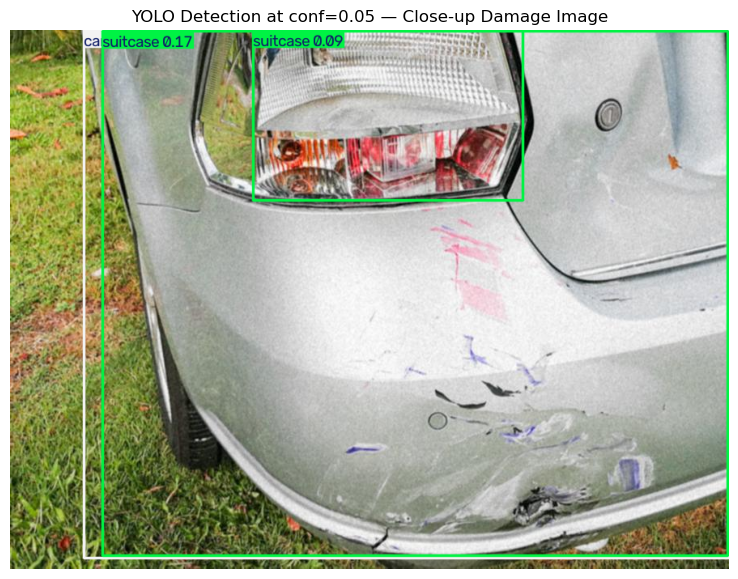

In [31]:
demo_image = "/home/jovyan/car_damage/images/6989.jpg"

results_default = yolo_model.predict(source=demo_image, conf=0.40, device=yolo_device, verbose=False)
n_default = 0 if results_default[0].boxes is None else len(results_default[0].boxes)

results_low = yolo_model.predict(source=demo_image, conf=0.05, device=yolo_device, verbose=False)
n_low = 0 if results_low[0].boxes is None else len(results_low[0].boxes)

print(f"Detections at conf=0.40: {n_default}")
print(f"Detections at conf=0.05: {n_low}")

annotated = cv2.cvtColor(results_low[0].plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 7))
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLO Detection at conf=0.05 — Close-up Damage Image")
plt.show()

### 11.2 Experimental Validation on 100 Quality-PASS Images

This is the historical validation experiment (distinct from the full-scale runtime detection in 11.3). YOLO is run at `conf=0.05` and compared against human ground truth (`yolo_manual_review_100.csv`).

In [32]:
YOLO_CONF = 0.05
n_samples = min(100, len(quality_pass_df))

yolo_experiment_sample = quality_pass_df.sample(n=n_samples, random_state=42).reset_index(drop=True)
yolo_experiment_records = []

for _, row in tqdm(yolo_experiment_sample.iterrows(), total=len(yolo_experiment_sample), desc="YOLO experiment"):
    results = yolo_model.predict(source=row["path"], conf=YOLO_CONF, device=yolo_device, verbose=False)
    result = results[0]

    best_conf = 0.0
    car_count = 0
    if result.boxes is not None:
        for box in result.boxes:
            if int(box.cls[0]) == 2:  # COCO class 2 = car
                car_count += 1
                best_conf = max(best_conf, float(box.conf[0]))

    yolo_experiment_records.append({"image": row["image"], "path": row["path"],
                                     "best_car_confidence": best_conf, "car_count": car_count})

yolo_experiment_df = pd.DataFrame(yolo_experiment_records)
print("Experiment sample:", len(yolo_experiment_df))

YOLO experiment:   0%|          | 0/100 [00:00<?, ?it/s]

Experiment sample: 100


In [33]:
yolo_review_file = "/home/jovyan/car_damage/yolo_manual_review_100.csv"

if os.path.exists(yolo_review_file):
    yolo_review_df = pd.read_csv(yolo_review_file)
    yolo_review_df["actual_car"] = yolo_review_df["actual_car"].astype(str).str.strip().str.upper()

    yolo_eval_df = yolo_experiment_df.merge(yolo_review_df[["image", "actual_car"]], on="image", how="inner")

    y_true_yolo = (yolo_eval_df["actual_car"] == "YES").astype(int)
    y_pred_yolo = (yolo_eval_df["best_car_confidence"] >= YOLO_CONF).astype(int)

    yolo_metrics = evaluate_predictions(y_true_yolo, y_pred_yolo)
    tn, fp, fn, tp = confusion_matrix(y_true_yolo, y_pred_yolo, labels=[0, 1]).ravel()

    print(f"YOLO Experimental Performance (conf={YOLO_CONF}, n={len(yolo_eval_df)})")
    print("=" * 60)
    for k, v in yolo_metrics.items():
        print(f"{k.capitalize():10s}: {v*100:.2f}%")
    print(f"\nConfusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}")
else:
    print("No saved human review file found for the YOLO experiment sample:", yolo_review_file)

YOLO Experimental Performance (conf=0.05, n=100)
Accuracy  : 60.00%
Precision : 87.18%
Recall    : 49.28%
F1        : 62.96%

Confusion Matrix: TN=26  FP=5  FN=35  TP=34


**Conclusion:** the pretrained generic YOLO detector is **not reliable enough** to hard-reject images on its own — recall is too low, so relying on it alone would wrongly discard valid damage photos. It is therefore used only as a *first pass*, with uncertain cases routed to human review (Section 12).

### 11.3 Full-Scale Vehicle Detection on All Quality-PASS Images

Runs YOLO once over every image that passed the quality gate (Section 10), to drive the runtime fallback in Section 12. Loaded from a saved file if it already exists.

In [34]:
yolo_full_results_file = "/home/jovyan/car_damage/yolo_vehicle_validation_results.csv"

if os.path.exists(yolo_full_results_file):
    yolo_full_df = pd.read_csv(yolo_full_results_file)
    print("Loaded saved YOLO full-dataset results:", yolo_full_results_file)
else:
    yolo_full_records = []
    for _, row in tqdm(quality_pass_df.iterrows(), total=len(quality_pass_df), desc="YOLO — all quality-PASS images"):
        image_path = row["path"]
        try:
            results = yolo_model.predict(source=image_path, conf=YOLO_CONF, device=yolo_device, verbose=False)
            result = results[0]
            best_conf = 0.0
            car_count = 0
            if result.boxes is not None:
                for box in result.boxes:
                    if int(box.cls[0]) == 2:
                        car_count += 1
                        best_conf = max(best_conf, float(box.conf[0]))
        except Exception as e:
            print(f"YOLO error on {row['image']}: {e}")
            best_conf, car_count = 0.0, 0

        yolo_full_records.append({
            "image": row["image"], "path": image_path,
            "yolo_car_confidence": best_conf,
            "yolo_car_detected": car_count > 0,
        })

    yolo_full_df = pd.DataFrame(yolo_full_records)
    yolo_full_df.to_csv(yolo_full_results_file, index=False)
    print("Saved:", yolo_full_results_file)

print("Total scored:", len(yolo_full_df))
print("YOLO detected a car:", int(yolo_full_df["yolo_car_detected"].sum()))
print("YOLO did not detect a car:", int((~yolo_full_df["yolo_car_detected"]).sum()))

Loaded saved YOLO full-dataset results: /home/jovyan/car_damage/yolo_vehicle_validation_results.csv
Total scored: 3267
YOLO detected a car: 1341
YOLO did not detect a car: 1926


# 12. Runtime Human Review — Vehicle Presence Fallback

Images where YOLO confidently detects a vehicle continue automatically. Images where it does not are queued for a human reviewer, who answers *"Is there a vehicle or a clear vehicle part visible in the image?"* (YES/NO). Saved to `yolo_human_review_queue.csv`, kept separate from the quality-review queue in Section 10.

In [35]:
def show_vehicle_review_item(row):
    image = cv2.imread(row["path"])
    if image is not None:
        results = yolo_model.predict(source=row["path"], conf=YOLO_CONF, device=yolo_device, verbose=False)
        annotated = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(9, 6))
        plt.imshow(annotated)
        plt.axis("off")
        plt.title(row["image"], fontsize=13)
        plt.show()

    print("=" * 60)
    print("Image                :", row["image"])
    conf_val = row["yolo_car_confidence"]
    print(f"YOLO car confidence  : {conf_val:.3f}")
    print("YOLO car detected    :", row["yolo_car_detected"])
    print("=" * 60)


vehicle_review_queue_file = "/home/jovyan/car_damage/yolo_human_review_queue.csv"

vehicle_review_queue = yolo_full_df[~yolo_full_df["yolo_car_detected"]][
    ["image", "path", "yolo_car_confidence", "yolo_car_detected"]
].reset_index(drop=True)

print("Images queued for vehicle human review:", len(vehicle_review_queue))

# Set to True to open the interactive review loop for any unreviewed images
RUN_VEHICLE_REVIEW = False

if RUN_VEHICLE_REVIEW:
    vehicle_review_queue = run_human_review(
        vehicle_review_queue,
        vehicle_review_queue_file,
        id_col="image",
        decision_col="vehicle_human_decision",
        question="Is there a vehicle or a clear vehicle part visible in the image?",
        show_fn=show_vehicle_review_item,
    )
elif os.path.exists(vehicle_review_queue_file):
    saved = pd.read_csv(vehicle_review_queue_file)
    vehicle_review_queue = vehicle_review_queue.merge(
        saved[["image", "vehicle_human_decision"]], on="image", how="left"
    )
    print("Loaded existing vehicle review decisions:", vehicle_review_queue_file)
else:
    vehicle_review_queue["vehicle_human_decision"] = np.nan

Images queued for vehicle human review: 1926


# 13. Final Image Validation Pipeline

Combines the suspicion-and-quality gate (Section 10 — automated + external human decision) and vehicle-presence gate (Section 12) into the final per-image decision. `decision_authority` on every row shows whether the quality call was made by the AI (`AUTOMATED_AI`) or by an external human reviewer (`EXTERNAL_HUMAN`).

In [36]:
final_df = yolo_full_df[["image", "path", "yolo_car_detected", "yolo_car_confidence"]].merge(
    vehicle_review_queue[["image", "vehicle_human_decision"]], on="image", how="left"
)

final_df["final_vehicle_pass"] = (
    final_df["yolo_car_detected"] | (final_df["vehicle_human_decision"] == "YES")
)

# Bring in the quality-gate columns for every image (not just quality-PASS ones)
final_df = quality_results.merge(
    final_df.drop(columns=["path"]), on="image", how="left"
)

final_df["yolo_car_detected"] = final_df["yolo_car_detected"].fillna(False)
final_df["final_vehicle_pass"] = final_df["final_vehicle_pass"].fillna(False)

final_df["final_image_valid"] = final_df["final_quality_pass"] & final_df["final_vehicle_pass"]

output_columns = [
    "image", "path", "automated_quality_pass", "is_suspicious", "suspicion_reason",
    "arabic_text_detected", "quality_human_decision", "decision_authority", "final_quality_pass",
    "yolo_car_detected", "yolo_car_confidence", "vehicle_human_decision", "final_vehicle_pass",
    "final_image_valid",
]
final_df = final_df[output_columns]

final_dataset_file = "/home/jovyan/car_damage/final_images_for_damage_detection.csv"
final_df.to_csv(final_dataset_file, index=False)

print("FINAL IMAGE VALIDATION PIPELINE")
print("=" * 60)
print("Total images        :", len(final_df))
print("Final quality PASS  :", int(final_df["final_quality_pass"].sum()))
print("Final vehicle PASS  :", int(final_df["final_vehicle_pass"].sum()))
print("Final image VALID   :", int(final_df["final_image_valid"].sum()))
print("\nSaved:", final_dataset_file)

final_df.head()

FINAL IMAGE VALIDATION PIPELINE
Total images        : 8079
Final quality PASS  : 3258
Final vehicle PASS  : 1341
Final image VALID   : 1335

Saved: /home/jovyan/car_damage/final_images_for_damage_detection.csv


,image,path,automated_quality_pass,is_suspicious,suspicion_reason,arabic_text_detected,quality_human_decision,decision_authority,final_quality_pass,yolo_car_detected,yolo_car_confidence,vehicle_human_decision,final_vehicle_pass,final_image_valid
0,4187.jpg,/home/jovyan/car_damage/images/4187.jpg,False,True,QUALITY_BORDERLINE,False,NaN,EXTERNAL_HUMAN,False,True,0.063601,NaN,True,False
1,7447.jpg,/home/jovyan/car_damage/images/7447.jpg,False,True,QUALITY_BORDERLINE,False,NaN,EXTERNAL_HUMAN,False,False,0.000000,NaN,False,False
2,2713.jpg,/home/jovyan/car_damage/images/2713.jpg,False,False,NONE,False,NaN,AUTOMATED_AI,False,False,NaN,NaN,False,False
3,3649.jpg,/home/jovyan/car_damage/images/3649.jpg,False,True,QUALITY_BORDERLINE,False,NaN,EXTERNAL_HUMAN,False,True,0.088155,NaN,True,False
4,4025.jpg,/home/jovyan/car_damage/images/4025.jpg,False,False,NONE,False,NaN,AUTOMATED_AI,False,False,NaN,NaN,False,False


# 14. Final Results

**Dataset:** 8,079 total images.

**Automated quality gate (Section 8):**
- Technical PASS: 4,061 | Technical FAIL: 4,018
- MANIQA PASS: 6,061 | MANIQA FAIL: 2,018
- Automated Quality PASS: 3,258 (40.33%) | FAIL: 4,821 (59.67%)

**Human validation of the calibrated quality pipeline** (100-image reference, Section 7.4): Accuracy 78.0%, Precision 66.7%, Recall 70.6%, F1 68.6% (TN=54, FP=12, FN=10, TP=24) — a clear improvement over technical checks alone (Accuracy 64.0%, Precision 47.9%, Recall 67.6%, F1 56.1%, TN=41, FP=25, FN=11, TP=23).

**Dominant failure reasons (Section 9):** blur (alone or combined with other checks) accounts for the largest share of rejections, followed by MANIQA (perceptual quality) and contrast.

**Suspicious-image routing (Section 10):** two independent AI *flags* — quality-borderline (automated FAIL close to the calibrated thresholds) and Arabic-text/document detection (OCR) — send an image to review; the AI never decides these cases itself. The YES/NO call is made by an external human reviewer (the system owner / assigned team member), stamped `decision_authority = EXTERNAL_HUMAN` for audit; only images that remain rejected after that external review are excluded.

**YOLO vehicle-presence experiment (Section 11):** best tested confidence threshold 0.05 — Accuracy 60%, Precision 87.18%, Recall 49.28%, F1 62.96%. Recall is too low for YOLO to be used as a hard rejection filter on close-up damage photos, so uncertain cases are routed to human review (Section 12) instead of being auto-rejected.

Together, the automated checks and the two runtime human-review fallbacks (quality and vehicle presence) produce a validated dataset (`final_images_for_damage_detection.csv`) ready for the next phase.

# 15. Dataset Ready for Damage Detection

The Image Validation phase (automated checks + both runtime human-review fallbacks) is complete.

In [37]:
damage_detection_input = final_df[final_df["final_image_valid"]].copy()

print("Images ready for the next phase:", len(damage_detection_input))
damage_detection_input.head()

Images ready for the next phase: 1335


,image,path,automated_quality_pass,is_suspicious,suspicion_reason,arabic_text_detected,quality_human_decision,decision_authority,final_quality_pass,yolo_car_detected,yolo_car_confidence,vehicle_human_decision,final_vehicle_pass,final_image_valid
5,6989.jpg,/home/jovyan/car_damage/images/6989.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.150748,NaN,True,True
7,6925.jpg,/home/jovyan/car_damage/images/6925.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.078882,NaN,True,True
18,2796.jpg,/home/jovyan/car_damage/images/2796.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.084585,NaN,True,True
22,5605.jpg,/home/jovyan/car_damage/images/5605.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.358878,NaN,True,True
36,2766.jpg,/home/jovyan/car_damage/images/2766.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.455376,NaN,True,True


In [38]:
# Select only images that passed all validation stages
damage_detection_input = final_df[
    final_df["final_image_valid"] == True
].copy()

print("Images ready for the next phase:", len(damage_detection_input))

# Save the validated images list for the Damage Detection notebook
output_file = "/home/jovyan/car_damage/final_images_for_damage_detection.csv"

damage_detection_input.to_csv(output_file, index=False)

print(f"Saved successfully: {output_file}")

damage_detection_input.head()

Images ready for the next phase: 1335
Saved successfully: /home/jovyan/car_damage/final_images_for_damage_detection.csv


,image,path,automated_quality_pass,is_suspicious,suspicion_reason,arabic_text_detected,quality_human_decision,decision_authority,final_quality_pass,yolo_car_detected,yolo_car_confidence,vehicle_human_decision,final_vehicle_pass,final_image_valid
5,6989.jpg,/home/jovyan/car_damage/images/6989.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.150748,NaN,True,True
7,6925.jpg,/home/jovyan/car_damage/images/6925.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.078882,NaN,True,True
18,2796.jpg,/home/jovyan/car_damage/images/2796.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.084585,NaN,True,True
22,5605.jpg,/home/jovyan/car_damage/images/5605.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.358878,NaN,True,True
36,2766.jpg,/home/jovyan/car_damage/images/2766.jpg,True,False,NONE,False,NaN,AUTOMATED_AI,True,True,0.455376,NaN,True,True


**Next phase: Vehicle Damage Detection** — using `damage_detection_input` (images where `final_image_valid == True`) as input. Damage Detection itself is not implemented in this notebook.